# KNN con Carros

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, root_mean_squared_error, r2_score
from sklearn.compose import make_column_selector as selector
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV


In [2]:
carros = pd.read_csv("automobile_data.csv")


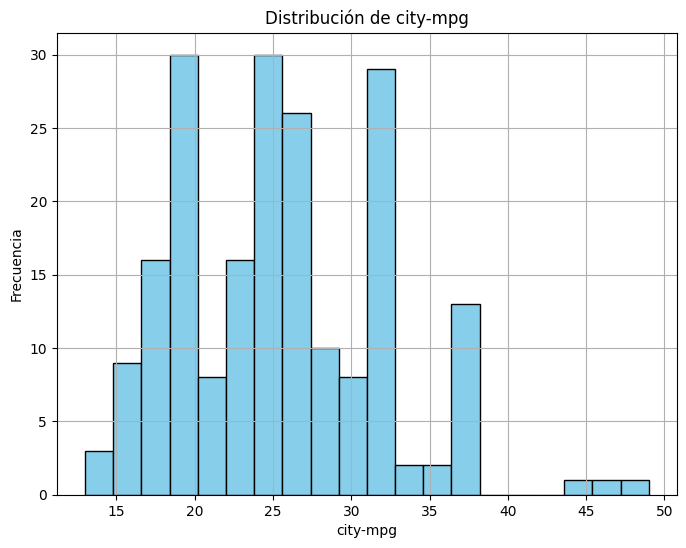

count    205.000000
mean      25.219512
std        6.542142
min       13.000000
25%       19.000000
50%       24.000000
75%       30.000000
max       49.000000
Name: city-mpg, dtype: float64


In [3]:
plt.figure(figsize=(8, 6))
plt.hist(carros['city-mpg'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribución de city-mpg')
plt.xlabel('city-mpg')
plt.ylabel('Frecuencia')
plt.grid(True)
plt.show()
print(carros['city-mpg'].describe())

***Número de filas:*** 205  
***Número de atributos o columnas:*** 26 

### Información de los atributos:  

|Atributo:|Rango del atributo:|
|--------:|:-------------------:|
|1. symboling:|-3, -2, -1, 0, 1, 2, 3.|
|2. normalized-losses:|numérico 65 hasta 256.|
|3. make:|alfa-romero, audi, bmw, chevrolet, dodge, honda, isuzu, jaguar, mazda, mercedes-benz, mercury, mitsubishi, nissan, peugot, plymouth, porsche,  renault, saab, subaru, hastayota, volkswagen, volvo|
|4. fuel-type:|diesel, gas.|
|5. aspiration:|std, turbo.|
|6. num-of-doors:|four, two.|
|7. body-style:|hardtop, wagon, sedan, hatchback, convertible.|
|8. drive-wheels:|4wd, fwd, rwd.|
|9. engine-location:|front, rear.|
|10. wheel-base:|numérico desde 86.6 hasta 120.9.|
|11. length:|numérico desde 141.1 hasta 208.1.|
|12. width:|numérico desde 60.3 hasta 72.3.|
|13. height:|numérico desde 47.8 hasta 59.8.|
|14. curb-weight:|numérico desde 1488 hasta 4066.|
|15. engine-type:|dohc, dohcv, l, ohc, ohcf, ohcv, rotor.|
|16. num-of-cylinders:|eight, five, four, six, three, twelve, two.|
|17. engine-size:|numérico desde 61 to 326.|
|18. fuel-system:|1bbl, 2bbl, 4bbl, idi, mfi, mpfi, spdi, spfi.|
|19. bore:|numérico desde 2.54 hasta 3.94.|
|20. stroke:|numérico desde 2.07 hasta 4.17.|
|21. compression-ratio:|numérico desde 7 hasta 23.|
|22. horsepower:|numérico desde 48 hasta 288.|
|23. peak-rpm:|numérico desde 4150 hasta 6600.|
|24. city-mpg:|numérico desde 13 hasta 49.|
|25. highway-mpg:|numérico desde 16 hasta 54.|
|26. price:|numérico desde 5118 hasta 45400.|



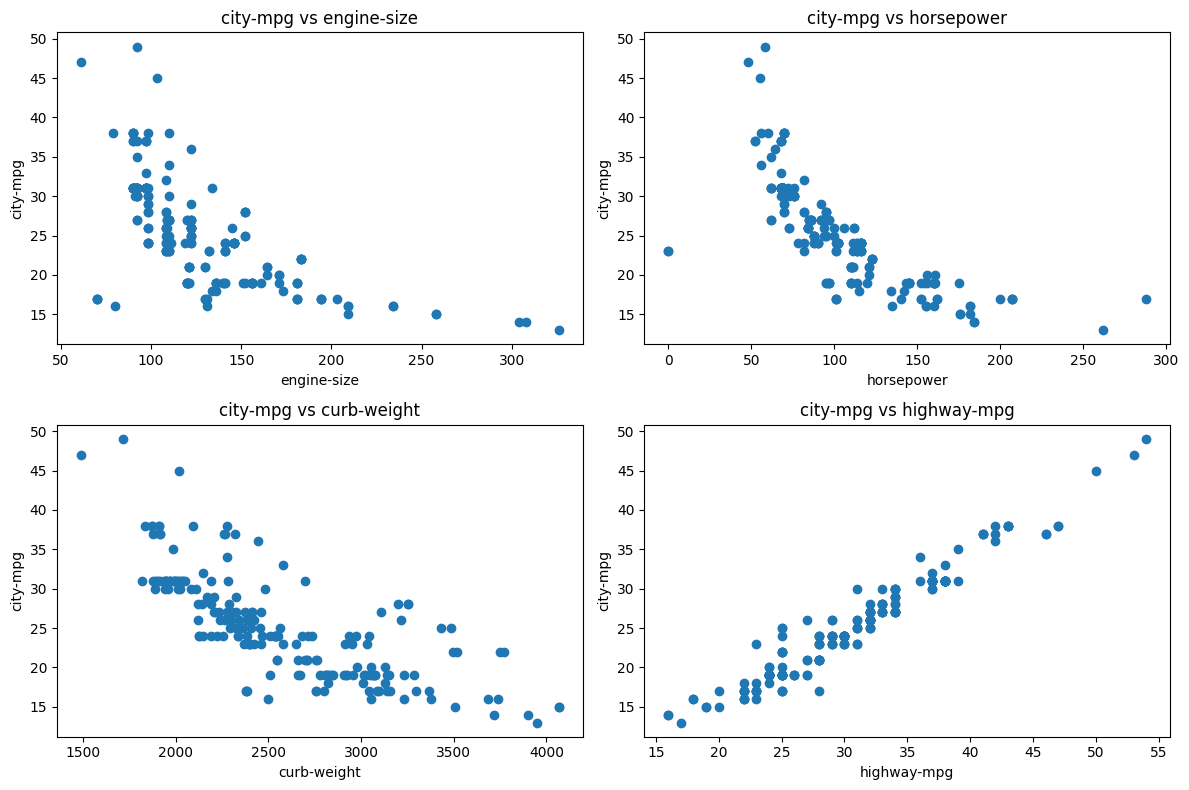

In [4]:
# VEAMOS EL COMPORTAMIENTO DE MI "Y" CON RESPECTO A ALGUNAS VARIABLES
features = ['engine-size', 'horsepower', 'curb-weight', 'highway-mpg']

plt.figure(figsize=(12, 8))

for i, col in enumerate(features):
    plt.subplot(2, 2, i+1)
    plt.scatter(carros[col], carros['city-mpg'])
    plt.xlabel(col)
    plt.ylabel('city-mpg')
    plt.title(f'city-mpg vs {col}')

plt.tight_layout()
plt.show()

## Variable Respuesta:

La variable que se pretende predecir es el consumo por galón en ciudad (city_mpg).
Separemos en conjuntos de entrenamiento y prueba.

## Conjuntos de entrenamiento y prueba.   

Se separarán en 70% de los datos en el conjunto de entrenamiento y 30% en el conjunto de prueba, usando un muestreo aleatorio simple.   

In [5]:
carros["bore"] = carros["bore"].fillna(carros["bore"].median())
carros["stroke"] = carros["stroke"].fillna(carros["stroke"].median())
carros["horsepower"] = carros["horsepower"].fillna(carros["horsepower"].median())
carros["peak-rpm"] = carros["peak-rpm"].fillna(carros["peak-rpm"].median())
carros["price"] = carros["price"].fillna(carros["price"].median())


carros.pop("normalized-losses")

0        0
1        0
2        0
3      164
4      164
      ... 
200     95
201     95
202     95
203     95
204     95
Name: normalized-losses, Length: 205, dtype: int64

In [6]:
print(carros.isnull().sum())

symboling            0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64


In [7]:
print(carros.dtypes)

symboling              int64
make                  object
fuel-type             object
aspiration            object
num-of-doors          object
body-style            object
drive-wheels          object
engine-location       object
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type           object
num-of-cylinders      object
engine-size            int64
fuel-system           object
bore                 float64
stroke               float64
compression-ratio    float64
horsepower             int64
peak-rpm               int64
city-mpg               int64
highway-mpg            int64
price                  int64
dtype: object


In [8]:
# Definición de X & Y
y = carros.pop("city-mpg")
X = carros

In [9]:
# Separación de datos (entrenamiento y pruebas)
X_train, X_test,y_train, y_test = train_test_split(X, y,test_size=0.3,train_size=0.7,random_state=0)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(143, 24)
(62, 24)
(143,)
(62,)


Separando variables en numéricas vs categóricas

In [10]:
numerical_columns_selector = selector(dtype_exclude=object)
categorical_columns_selector = selector(dtype_include=object)

numerical_columns = numerical_columns_selector(carros)
categorical_columns = categorical_columns_selector(carros)
print(categorical_columns)
print(numerical_columns)

['make', 'fuel-type', 'aspiration', 'num-of-doors', 'body-style', 'drive-wheels', 'engine-location', 'engine-type', 'num-of-cylinders', 'fuel-system']
['symboling', 'wheel-base', 'length', 'width', 'height', 'curb-weight', 'engine-size', 'bore', 'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'highway-mpg', 'price']


Vamos a codificar las variables cualitativas con un onehot encoder y vamos a normalizar las variables cuantitativas

In [11]:
categorical_preprocessor = OneHotEncoder(handle_unknown="ignore")
numerical_preprocessor = StandardScaler()
preprocessor = ColumnTransformer([
    ('one-hot-encoder', categorical_preprocessor, categorical_columns),
    ('standar-scaler', numerical_preprocessor,numerical_columns)
    ])

In [12]:
# Crear pipeline con KNN
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('knn', KNeighborsRegressor())
])

# Definir hiperparámetros a optimizar en la búsqueda
param_grid = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],  # Diferentes valores de k
    'knn__weights': ['uniform', 'distance'],  # Peso de los vecinos
    'knn__p': [1, 2]  # Distancia Manhattan (p=1) vs Euclidiana (p=2)
}

# Validación cruzada con 5 folds y GridSearch
grid_search = GridSearchCV(knn_pipeline, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('one-hot-encoder',
                                                                         OneHotEncoder(handle_unknown='ignore'),
                                                                         ['make',
                                                                          'fuel-type',
                                                                          'aspiration',
                                                                          'num-of-doors',
                                                                          'body-style',
                                                                          'drive-wheels',
                                                                          'engine-location',
                                                                          'engine-type',
                                                                          'num-of-cylinders',
                                                                          'fuel-system']),
                                                                        ('standar-scaler',
                                                                         StandardScaler(),
                                                                         ['symboling',
                                                                          'wheel-base',
                                                                          'length',
                                                                          'width',
                                                                          'height',
                                                                          'curb-weight',
                                                                          'engine-size',
                                                                          'bore',
                                                                          'stroke',
                                                                          'compression-ratio',
                                                                          'horsepower',
                                                                          'peak-rpm',
                                                                          'highway-mpg',
                                                                          'price'])])),
                                       ('knn', KNeighborsRegressor())]),
             n_jobs=-1,
             param_grid={'knn__n_neighbors': [3, 5, 7, 9, 11], 'knn__p': [1, 2],
                         'knn__weights': ['uniform', 'distance']},
             scoring='neg_mean_squared_error')

In [13]:
# Mejor modelo encontrado
best_knn = grid_search.best_estimator_
print(f"Mejor hiperparámetro: {grid_search.best_params_}")


Mejor hiperparámetro: {'knn__n_neighbors': 3, 'knn__p': 1, 'knn__weights': 'distance'}


In [14]:
# Evaluación en el conjunto de prueba
y_pred = best_knn.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE en test: {rmse}")
print(f"R² en test: {r2}")

RMSE en test: 3.213123708444153
R² en test: 0.8218757348096761


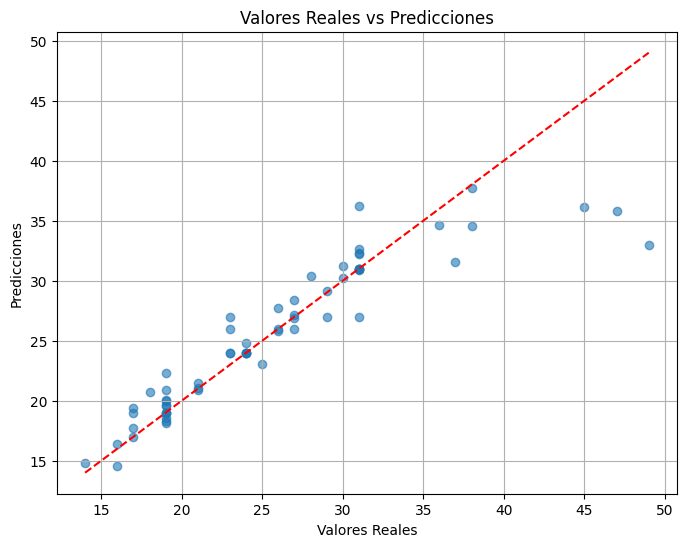

In [17]:
# Visualización de errores
# plt.scatter(y_test, y_pred)
# plt.xlabel("Valores Reales")
# plt.ylabel("Predicciones")
# plt.title("Comparación entre Valores Reales y Predicciones")
# plt.show()

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.6)

# línea ideal
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linestyle='--')

plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")
plt.title("Valores Reales vs Predicciones")
plt.grid(True)
plt.show()

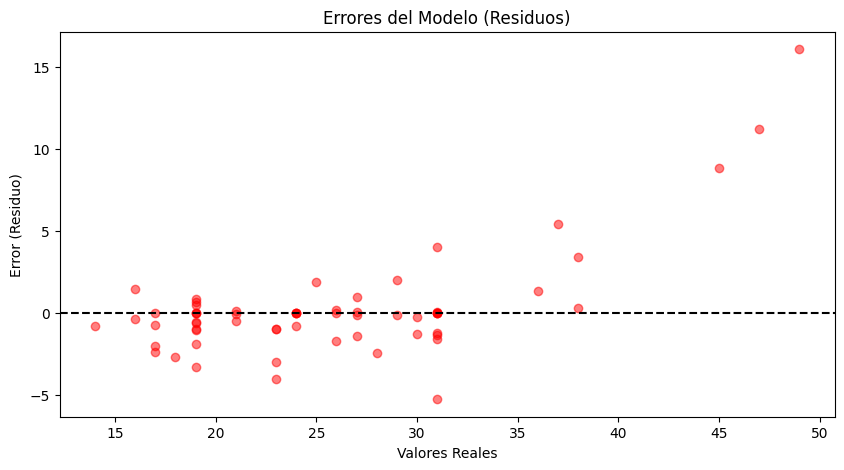

In [19]:
plt.figure(figsize=(10,5))
residuals = y_test - y_pred
plt.scatter(y_test, residuals, alpha=0.5, color='red')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlabel("Valores Reales")
plt.ylabel("Error (Residuo)")
plt.title("Errores del Modelo (Residuos)")
plt.show()

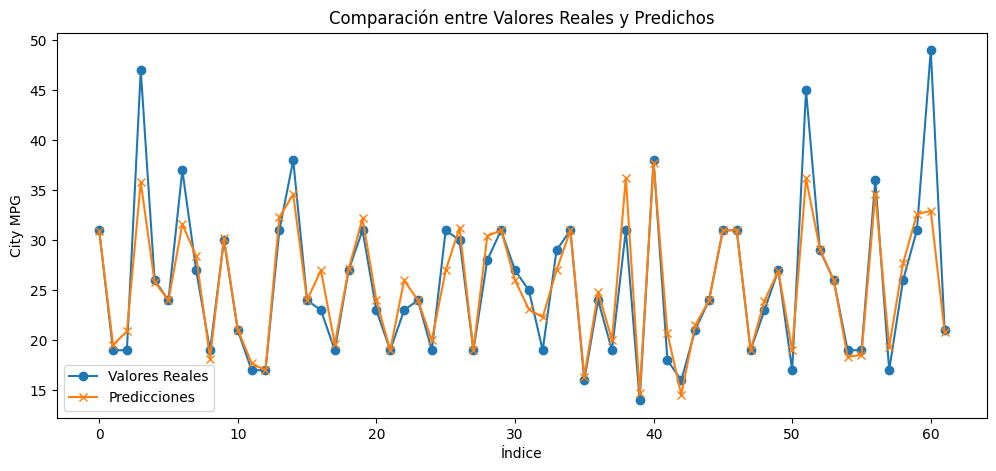

In [20]:
plt.figure(figsize=(12,5))
plt.plot(range(len(y_test)), y_test.values, label="Valores Reales", marker='o')
plt.plot(range(len(y_pred)), y_pred, label="Predicciones", marker='x')
plt.xlabel("Índice")
plt.ylabel("City MPG")
plt.title("Comparación entre Valores Reales y Predichos")
plt.legend()
plt.show()

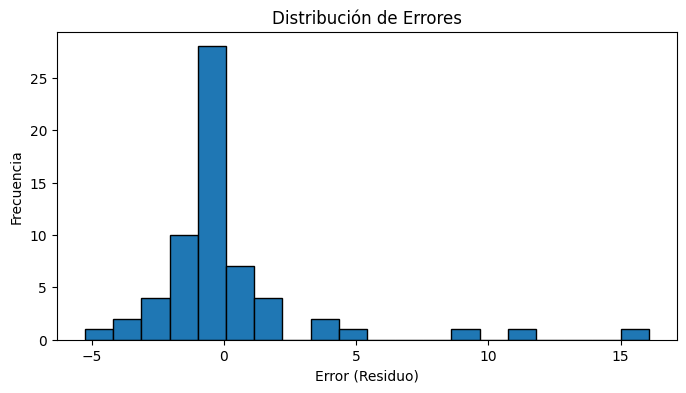

In [21]:
plt.figure(figsize=(8,4))
plt.hist(residuals, bins=20, edgecolor='black')
plt.xlabel("Error (Residuo)")
plt.ylabel("Frecuencia")
plt.title("Distribución de Errores")
plt.show()
